1.

No. They never use the phrase “branch-and-bound,” and they don’t say who coined it. In their 2010 introduction, they state, "We did not initially think of the method as 'branch and bound'". They mention they aren't sure if the term was already in the literature. They describe their automatic method in terms of splitting the problem into sets of solutions by adding extra constraints, and using "upper bounds" from the linear-programming relaxation to decide what to explore or discard. The paper doesn't give us any explicit author for "branch-and-bound" other than mentioning, "Much later someone wrote a paper about ‘shoulder branch and bound’".

The method selects a branching variable by finding the variable that is "furthest from an integer". After selecting a variable (like $x_r$), it "floors and ceils" it by creating two new problems: one with the new constraint that $x_r$ equals the integer just below its value (e.g., $[x_r^0]$), and one where $x_r$ equals the integer just above (e.g., $[x_r^0]+1$).

It then finds the solution (the $\gamma$ value) for both of these new problems and selects the one with the largest (maximize) objective value as the new best upper bound, or $\gamma^1$. The model then continues by taking this new problem, which now has a fixed integer value for $x_r$, and repeats the process by selecting the next variable that is furthest from an integer.

When an integer solution is found, it is only proven to be the optimum if its objective value is higher than the upper bounds of all other unexplored branches. The algorithm maintains a list of all potential branches and their $\gamma$ values, always exploring the one with the highest value. The computation is complete only when an integer solution is found and its $\gamma$ value is higher than any other $\gamma$ value remaining on the list.

2.
Based on the survey paper, the main node selection (or search) strategies mentioned are Depth-First Search (DFS), Breadth-First Search (BrFS), Best-First Search (BFS), and Cyclic Best-First Search (CBFS). The order of exploration is important because it significantly affects computation time and memory requirements, finding a good incumbent solution early in the search allows the algorithm to prune more of the search tree, thus reducing the total number of nodes that must be explored to verify optimality. 

The paper discusses branching strategies, which are categorized into binary and wide branching, and also mentions specific variable selection rules for integer programming, such as pseudocost branching, strong branching, and the "most fractional" rule. However, the paper states that the "most fractional" rule is not a good strategy, noting that it is generally no better than selecting a branching variable at random in terms of computational time or the number of subproblems explored.

3.
Based on the "Experiments in mixed-integer linear programming" paper, pseudo-costs are computed automatically during the branch-and-bound tree scan to measure the "importance" of each integer variable. When the algorithm branches at a node *k* on a non-integer variable $y_b$ (which has a value $\overline{y}_{b}^{k}$ with integer part $[\overline{y}_{b}^{k}]$ and fractional part $f_b^k$), it creates a "down" node (*n+1*) and an "up" node (*n+2*). The lower pseudo-cost ($PCL_{b}$) is calculated as the change in the objective function on the down branch divided by the fractional part:

$$PCL_{b} = \left| \frac{\overline{F}_{n+1} - \overline{F}_{k}}{f_{b}^{k}} \right|$$

The upper pseudo-cost ($PCU_{b}$) is the change on the up branch divided by one minus the fractional part, representing the objective's deterioration per unit of change:

$$PCU_{b} = \left| \frac{\overline{F}_{n+2} - \overline{F}_{k}}{1 - f_{b}^{k}} \right|$$

This pseudo-cost are calculated reactively.

These pseudo-costs are then used in two primary ways:

1.  **To select the next branching node (via "estimations"):** An estimation $\overline{E}_{k}$ is calculated for each waiting node to forecast the best integer solution that can be expected from it. The node with the *best* (lowest) estimation is often chosen as the next node to explore. The formula is:
    $$\overline{E}_{k} = \overline{F}_{k} + \sum_{j} \min(PCL_{j} \cdot f_{j}^{k}, PCU_{j} \cdot (1-f_{j}^{k}))$$
    Here, $\overline{F}_{k}$ is the node's current objective value, and the sum represents the total *estimated penalty* to get to an integer solution, optimistically assuming each variable $j$ will be branched on in its "cheaper" direction.

2.  **To select the branching variable:** Once a node is selected, pseudo-costs are used to choose *which* fractional variable to branch on. The goal is to select the variable that causes the "greatest expected deterioration" of the objective, which can help prune branches faster. This is done by choosing the variable $j$ that maximizes the minimum expected penalty:
    $$\max_{j} \left( \min(PCL_{j} \cdot f_{j}^{k}, PCU_{j} \cdot (1-f_{j}^{k})) \right)$$
    This rule selects the variable whose *best-case* penalty (the $\min$ part) is still the *worst* (the $\max$ part) among all fractional variables, thus picking the variable that is "most expensive" to make integer.

4.
### Strong Branching

Strong branching is a method for selecting a branching variable in an integer program. The core idea is to find the variable that will cause the "most change in the objective function". To do this, it runs a test: for a subset of candidate fractional variables, it temporarily solves the LP relaxation for both the "up" branch (adding $x_i \ge \lceil \overline{x}_i \rceil$) and the "down" branch (adding $x_i \le \lfloor \overline{x}_i \rfloor$). After computing these new objective values for all candidates, it permanently selects the variable that gave the "best progress" (based on a score function) to be the *actual* branching variable for the current node. **Full strong branching** is when this test is performed for *all* fractional variables, which often leads to small search trees but is computationally expensive.


### Reliability Branching

Reliability branching is a hybrid strategy that defaults to using fast **pseudocosts** but selectively uses the expensive **strong branching** calculation *only* when a variable's pseudocost score is "unreliable".

To be precise, the **pseudocost** (which you can think of as a better $PCU$ or 'upward' score) is the **historical average** gain for a variable. The paper calls this average $\Psi_i^+$. This average is calculated using two other values:
* $\sigma_i^+$ is the **cumulative sum** of all *individual* upward gains (specifically, the $\zeta_i^+$ values, which represent the same "per-branch" calculation as the old $PCU$ from the previous problem) from *all previous encounters* where that variable was branched on.
* $\eta_i^+$ is the **count** of how many times that variable has been branched on in the "up" direction.

The **upward pseudocost** $\Psi_i^+$ is then the average: $\Psi_i^+ = \sigma_i^+ / \eta_i^+$.

Reliability branching **assesses "unreliability"** using these **counters** ($\eta_i^-$ and $\eta_i^+$) and a user-defined "reliability parameter" called $\eta_{rel}$.

A variable $i$ is officially considered **unreliable** if its historical count in *either* direction is less than this parameter. The exact check is:
$$\min\{\eta_i^-, \eta_i^+\} < \eta_{rel}$$

If a variable is deemed unreliable by this check, the algorithm will perform strong branching on it to get a high-quality objective gain value. This new result is then used to update the total sum ($\sigma_i$) and the count ($\eta_i$), making the average score ($\Psi_i^+$) more "reliable" for future decisions. If the variable's scores are already reliable (i.e., $\min\{\eta_i^-, \eta_i^+\} \ge \eta_{rel}$), the algorithm skips the expensive strong branching step and just trusts the stored pseudocost score.

# Problem 5

## Tree Visualization

The implementation now includes a tree visualization feature that plots the complete branch-and-bound tree. The visualization shows:

- **Node labels**: Each node displays its ID and LP relaxation value
- **Color coding**:
  - **Sky blue**: Explored nodes
  - **Light green**: Integer solutions (pruned by integrality)
  - **Light red**: Nodes pruned by bound
  - **Red**: Infeasible nodes
- **Tree structure**: Edges show parent-child relationships

The tree is plotted automatically after each solver run, helping to visualize the search process and understand how different branching strategies explore the solution space.

In [1]:
import pyomo.environ as pyo
from queue import PriorityQueue
import time
import math
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_agraph import graphviz_layout

# --- 1. Problem Data ---
# Based on the table in the PDF
profits = {
    1: 22, 2: 18, 3: 35, 4: 14, 5: 60, 6: 12,
    7: 50, 8: 15, 9: 21, 10: 19, 11: 24, 12: 16
}
weights = {
    1: 5, 2: 6, 3: 8, 4: 4, 5: 11, 6: 3,
    7: 10, 8: 4, 9: 6, 10: 5, 11: 7, 12: 5
}
# Capacities
capacities = {1: 22, 2: 19}

# Item and Knapsack sets (using n=12)
ITEMS = list(profits.keys())
KNAPSACKS = list(capacities.keys())

In [2]:
# --- 2. B&B Node Class ---
class BBNode:
    """A class to represent a node in the B&B tree."""
    
    def __init__(self, node_id, parent_id, bounds_applied, lp_value, lp_solution, is_integer, was_pruned=False, prune_reason="", branch_var=None, branch_val=None):
        self.node_id = node_id
        self.parent_id = parent_id
        self.bounds_applied = bounds_applied  # Dict {(i, j): val} of fixed vars
        self.lp_value = lp_value
        self.lp_solution = lp_solution
        self.is_integer = is_integer
        self.was_pruned = was_pruned
        self.prune_reason = prune_reason
        self.branch_var = branch_var  # The variable that was branched on to create this node
        self.branch_val = branch_val  # The value (0 or 1) assigned to the branch variable

    # This makes the PriorityQueue a Max-Heap based on lp_value
    def __lt__(self, other):
        return self.lp_value > other.lp_value

In [3]:
# --- 3. Pyomo Model Functions ---
def create_base_model():
    """Creates the base Pyomo model structure for the MKP."""
    model = pyo.ConcreteModel()
    
    # Sets
    model.I = pyo.Set(initialize=ITEMS)
    model.J = pyo.Set(initialize=KNAPSACKS)
    
    # Parameters
    model.p = pyo.Param(model.I, initialize=profits)
    model.w = pyo.Param(model.I, initialize=weights)
    model.C = pyo.Param(model.J, initialize=capacities)
    
    # Variables: x_ij
    # We define them as Reals between 0 and 1 for the LP relaxation
    model.x = pyo.Var(model.I, model.J, within=pyo.NonNegativeReals, bounds=(0, 1))
    
    # Objective: Maximize total profit
    def obj_rule(m):
        return sum(m.p[i] * m.x[i, j] for i in m.I for j in m.J)
    model.obj = pyo.Objective(rule=obj_rule, sense=pyo.maximize)
    
    # Constraint 1: Knapsack capacity
    def capacity_rule(m, j):
        return sum(m.w[i] * m.x[i, j] for i in m.I) <= m.C[j]
    model.capacity_con = pyo.Constraint(model.J, rule=capacity_rule)
    
    # Constraint 2: Each item in at most one knapsack
    def item_once_rule(m, i):
        return sum(m.x[i, j] for j in m.J) <= 1
    model.item_once_con = pyo.Constraint(model.I, rule=item_once_rule)
    
    return model

def solve_node_lp(solver, bounds_to_apply):
    """Creates, solves, and returns the result of a single LP relaxation."""
    model = create_base_model()
    
    # Apply the bounds for this specific node
    for (i, j), val in bounds_to_apply.items():
        model.x[i, j].fix(val)
        
    # Solve the LP with load_solutions=False to avoid warnings for infeasible cases
    try:
        results = solver.solve(model, tee=False, load_solutions=False)
    except Exception as e:
        print(f"Solver error: {e}")
        return 'error', None, None, False

    # --- Process Results ---
    
    # Check status
    status = results.solver.termination_condition
    if status == pyo.TerminationCondition.infeasible:
        return 'infeasible', None, None, False
    if status != pyo.TerminationCondition.optimal:
        # print(f"Warning: Node solve was not optimal. Status: {status}")
        return 'suboptimal', None, None, False

    # Load the solution only if optimal
    model.solutions.load_from(results)
    
    # Extract solution
    lp_value = model.obj()
    lp_solution = {}
    is_integer = True
    epsilon = 1e-6  # Tolerance for integrality

    for i in ITEMS:
        for j in KNAPSACKS:
            val = model.x[i, j].value
            if val is None:
                val = 0  # Handle non-assignment
            
            lp_solution[(i, j)] = val
            
            # Check for fractional values
            if abs(val - round(val)) > epsilon:
                is_integer = False
                
    return 'optimal', lp_value, lp_solution, is_integer

In [4]:
# --- 4. Greedy Heuristic ---
def greedy_heuristic():
    """Greedy heuristic for the multi-knapsack problem.
    Sorts items by profit/weight ratio and assigns each item to the knapsack
    with the most remaining capacity (if it fits).
    
    Returns:
    - heuristic_value: Total profit of the greedy solution
    - heuristic_solution: Dictionary mapping (item, knapsack) -> 1 for assigned items
    """
    # Calculate profit-to-weight ratios
    ratios = [(i, profits[i] / weights[i]) for i in ITEMS]
    # Sort items by ratio in descending order (best items first)
    ratios.sort(key=lambda x: x[1], reverse=True)
    
    # Initialize remaining capacities
    remaining_capacity = {j: capacities[j] for j in KNAPSACKS}
    
    # Initialize solution
    heuristic_solution = {}
    total_profit = 0
    
    # Greedily assign items
    for item, ratio in ratios:
        # Find the knapsack with the most remaining capacity that can fit this item
        best_knapsack = None
        max_remaining = -1
        
        for knapsack in KNAPSACKS:
            if remaining_capacity[knapsack] >= weights[item]:
                if remaining_capacity[knapsack] > max_remaining:
                    max_remaining = remaining_capacity[knapsack]
                    best_knapsack = knapsack
        
        # Assign item to the best knapsack if one was found
        if best_knapsack is not None:
            heuristic_solution[(item, best_knapsack)] = 1
            remaining_capacity[best_knapsack] -= weights[item]
            total_profit += profits[item]
    
    return total_profit, heuristic_solution

# --- 5. Branching Strategy Functions ---
def select_branch_var_most_fractional(lp_solution):
    """Finds the variable closest to 0.5."""
    best_var = None
    min_dist_to_05 = 0.51  # Start high
    
    for (i, j), val in lp_solution.items():
        if abs(val - round(val)) > 1e-6:  # If fractional
            dist = abs(val - 0.5)
            if dist < min_dist_to_05:
                min_dist_to_05 = dist
                best_var = (i, j)
                
    return best_var

def select_branch_var_strong(solver, current_bounds, fractional_vars, parent_lp_val):
    """Implements Strong Branching.
    Solves the LP for both children of each fractional variable and selects
    the variable that induces the MOST CHANGE in the objective function.
    
    For maximization: change = |parent_value - child_value| (absolute degradation)
    We want the variable that causes the most total change across both children.
    
    Reference: Applegate et al. [65] - variable selection for TSP
    
    Returns: (best_var, children_data, num_lp_solves)
    """
    best_var = None
    best_score = -math.inf  # We want to maximize the total change
    
    # Store results to avoid re-solving when creating children
    children_lp_data = {}
    num_lp_solves = 0
    
    for (i, j), frac_val in fractional_vars:
        
        # --- 1. Test "Down" Branch (var = 0) ---
        down_bounds = current_bounds.copy()
        down_bounds[(i, j)] = 0
        status, down_val, down_sol, down_int = solve_node_lp(solver, down_bounds)
        num_lp_solves += 1
        
        if status == 'optimal':
            # Change in objective (degradation for maximization)
            degradation_down = parent_lp_val - down_val
            children_lp_data[((i, j), 0)] = (status, down_val, down_sol, down_int)
        else:
            # Infeasible branch => use a large penalty
            degradation_down = parent_lp_val  # Maximum possible degradation
            children_lp_data[((i, j), 0)] = (status, None, None, False)
            
        # --- 2. Test "Up" Branch (var = 1) ---
        up_bounds = current_bounds.copy()
        up_bounds[(i, j)] = 1
        status, up_val, up_sol, up_int = solve_node_lp(solver, up_bounds)
        num_lp_solves += 1
        
        if status == 'optimal':
            # Change in objective (degradation for maximization)
            degradation_up = parent_lp_val - up_val
            children_lp_data[((i, j), 1)] = (status, up_val, up_sol, up_int)
        else:
            # Infeasible branch => use a large penalty
            degradation_up = parent_lp_val  # Maximum possible degradation
            children_lp_data[((i, j), 1)] = (status, None, None, False)
            
        # --- 3. Score the variable ---
        # Total change = sum of degradations in both children
        # This selects the variable that induces the MOST total change
        total_change = degradation_down + degradation_up
        current_score = max(degradation_down, degradation_up)

        if current_score > best_score:
            best_score = current_score
            best_var = (i, j)
            
    # Filter children_lp_data to only include data for the chosen variable
    final_children_data = {}
    if best_var:
        key_down = (best_var, 0)
        key_up = (best_var, 1)
        if key_down in children_lp_data:
            final_children_data[0] = children_lp_data[key_down]
        if key_up in children_lp_data:
            final_children_data[1] = children_lp_data[key_up]
            
    return best_var, final_children_data, num_lp_solves

In [5]:
# --- 5.5 Tree Plotting Function ---
def plot_bb_tree(all_nodes, strategy_name):
    """
    Plots the branch-and-bound tree showing nodes and their LP values.

    Parameters:
    - all_nodes: List of BBNode objects representing the entire tree
    - strategy_name: String name of the branching strategy used
    """
    if not all_nodes:
        print("No nodes to plot.")
        return

    # Create directed graph
    G = nx.DiGraph()

    # Add nodes and edges, track colors by node_id
    node_labels = {}
    node_color_map = {}
    node_edge_colors = {}  # Track edge colors for explored vs non-explored
    edge_labels = {}
    explored_count = 0

    for node in all_nodes:
        G.add_node(node.node_id)

        # Create label with node ID and LP value
        if node.lp_value is not None:
            node_labels[node.node_id] = f"N{node.node_id}\n{node.lp_value:.2f}"
        else:
            node_labels[node.node_id] = f"N{node.node_id}\nInf"

        # A node is "explored" (taken from queue and branched on) if:
        # - It's NOT pruned AND NOT an integer solution
        # This matches the node_count in the main solver
        was_explored = not node.was_pruned and not node.is_integer
        
        if was_explored:
            explored_count += 1

        # Color nodes based on their status
        if node.was_pruned:
            if "bound" in node.prune_reason.lower():
                # Light red for pruned by bound
                node_color_map[node.node_id] = '#FFB6C6'
            elif "infeasible" in node.prune_reason.lower():
                node_color_map[node.node_id] = '#FF6B6B'  # Red for infeasible
            elif "integrality" in node.prune_reason.lower():
                # Light green for integer solution
                node_color_map[node.node_id] = '#90EE90'
            else:
                # Gray for other pruning
                node_color_map[node.node_id] = '#D3D3D3'
        else:
            # Sky blue for explored nodes
            node_color_map[node.node_id] = '#87CEEB'

        # Add edge from parent with branching variable label
        if node.parent_id is not None:
            G.add_edge(node.parent_id, node.node_id)
            # Color edge based on whether child was explored
            node_edge_colors[(node.parent_id, node.node_id)] = 'black' if was_explored else 'lightgray'
            # Add edge label showing the branching variable and value
            if node.branch_var is not None:
                var_label = f"x{node.branch_var}={node.branch_val}"
                edge_labels[(node.parent_id, node.node_id)] = var_label

    # Get node colors and edge colors in the correct order
    node_colors = [node_color_map[node] for node in G.nodes()]
    edge_colors = [node_edge_colors.get((u, v), 'lightgray') for u, v in G.edges()]
    edge_widths = [3 if node_edge_colors.get((u, v), 'lightgray') == 'black' else 1.5 for u, v in G.edges()]

    # Custom improved hierarchical layout that uses all available space
    def improved_hierarchy_pos(G, root=0):
        """
        Creates a hierarchical layout that distributes nodes evenly across available space.
        Each level gets the full width, and nodes are spread to use all horizontal space.
        """
        # First, organize nodes by level
        levels = {root: 0}
        nodes_at_level = {0: [root]}
        queue = [root]
        visited = {root}

        while queue:
            node = queue.pop(0)
            level = levels[node]
            for child in G.neighbors(node):
                if child not in visited:
                    visited.add(child)
                    levels[child] = level + 1
                    if level + 1 not in nodes_at_level:
                        nodes_at_level[level + 1] = []
                    nodes_at_level[level + 1].append(child)
                    queue.append(child)

        # Calculate positions - use partial width with controlled spread
        pos = {}
        max_level = max(nodes_at_level.keys())

        for level, nodes in nodes_at_level.items():
            n_nodes = len(nodes)

            # Use a width factor that grows moderately with the number of nodes
            # This keeps small levels compact while giving more space to crowded levels
            width_factor = min(0.9, 0.3 + (n_nodes * 0.05)
                               )  # Range from 0.3 to 0.9

            if n_nodes == 1:
                # Center single nodes
                x_positions = [0.5]
            else:
                # Spread nodes across a portion of width, centered
                left_margin = (1 - width_factor) / 2
                right_margin = 1 - left_margin
                x_positions = [left_margin + i * (width_factor / (n_nodes - 1))
                               for i in range(n_nodes)]

            # Y position decreases with depth
            y = 1 - (level / max(1, max_level))

            for i, node in enumerate(nodes):
                pos[node] = (x_positions[i], y)

        return pos

    # Try to use graphviz dot for proper tree layout
    try:
        from networkx.drawing.nx_agraph import graphviz_layout
        # Use 'dot' program with moderate spacing for tree-like structure
        pos = graphviz_layout(
            G, prog='dot', args='-Grankdir=TB -Granksep=2.0 -Gnodesep=1.2')
        layout_method = "graphviz"
    except Exception as e:
        print(f"Graphviz not available ({e}). Using improved custom layout...")
        # Use improved custom layout that spreads nodes across full width
        pos = improved_hierarchy_pos(G, root=0)
        layout_method = "custom"

    # Create figure with much larger size for better spacing
    plt.figure(figsize=(40, 24))

    # Draw the graph
    nx.draw(G, pos,
            node_color=node_colors,
            node_size=3500,
            with_labels=False,
            arrows=True,
            edge_color=edge_colors,
            arrowsize=25,
            arrowstyle='->',
            width=edge_widths,
            linewidths=2.5,
            edgecolors='black')

    # Draw node labels
    nx.draw_networkx_labels(G, pos, node_labels,
                            font_size=11, font_weight='bold')

    # Draw edge labels (branching variables)
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=10,
                                 bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='gray', alpha=0.9))

    # Add title and legend
    title = f'Branch-and-Bound Tree - {strategy_name} Strategy\nTotal Nodes: {len(all_nodes)} | Explored Nodes: {explored_count}'
    if layout_method == "custom":
        title += "\n(Install pygraphviz for optimal tree layout)"
    plt.title(title, fontsize=16, fontweight='bold', pad=20)

    # Create custom legend
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor='#87CEEB', edgecolor='black', label='Explored & Branched'),
        Patch(facecolor='#90EE90', edgecolor='black', label='Integer Solution (Fathomed)'),
        Patch(facecolor='#FFB6C6', edgecolor='black', label='Pruned by Bound'),
        Patch(facecolor='#FF6B6B', edgecolor='black', label='Infeasible'),
        Line2D([0], [0], color='black', linewidth=3, label='Led to branching'),
        Line2D([0], [0], color='lightgray', linewidth=1.5, label='Fathomed immediately')
    ]
    plt.legend(handles=legend_elements, loc='upper left', fontsize=12)

    plt.axis('off')
    plt.tight_layout()
    plt.show()


--- Starting B&B with 'most_fractional' Strategy ---
Initial Lower Bound (Greedy Heuristic): 179
Heuristic Solution:
  Item 5 -> Knapsack 1 (profit: 60, weight: 11)
  Item 7 -> Knapsack 2 (profit: 50, weight: 10)
  Item 1 -> Knapsack 1 (profit: 22, weight: 5)
  Item 3 -> Knapsack 2 (profit: 35, weight: 8)
  Item 6 -> Knapsack 1 (profit: 12, weight: 3)
Initial Upper Bound (Root LP): 194.200
Node 20: Infeasible. Pruning.
Node 29: Pruning by integrality.
*** New Incumbent Found! Node 29, Value: 194.00 ***
Node 38: Infeasible. Pruning.
Node 42: Infeasible. Pruning.
Node 19: Pruning by integrality.
Node 52: Infeasible. Pruning.
Node 58: Infeasible. Pruning.
Node 56: Pruning by integrality.
Node 34: Pruning by bound (193.62 < 194.0)
Node 26: Pruning by bound (193.62 < 194.0)
Node 12: Pruning by bound (193.60 < 194.0)
Node 33: Pruning by bound (193.50 < 194.0)
Node 23: Pruning by bound (193.30 < 194.0)
Node 22: Pruning by bound (192.95 < 194.0)
Node 31: Pruning by bound (184.00 < 194.0)
Node

C:\Users\Anh\AppData\Local\Temp\ipykernel_10776\2294477973.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


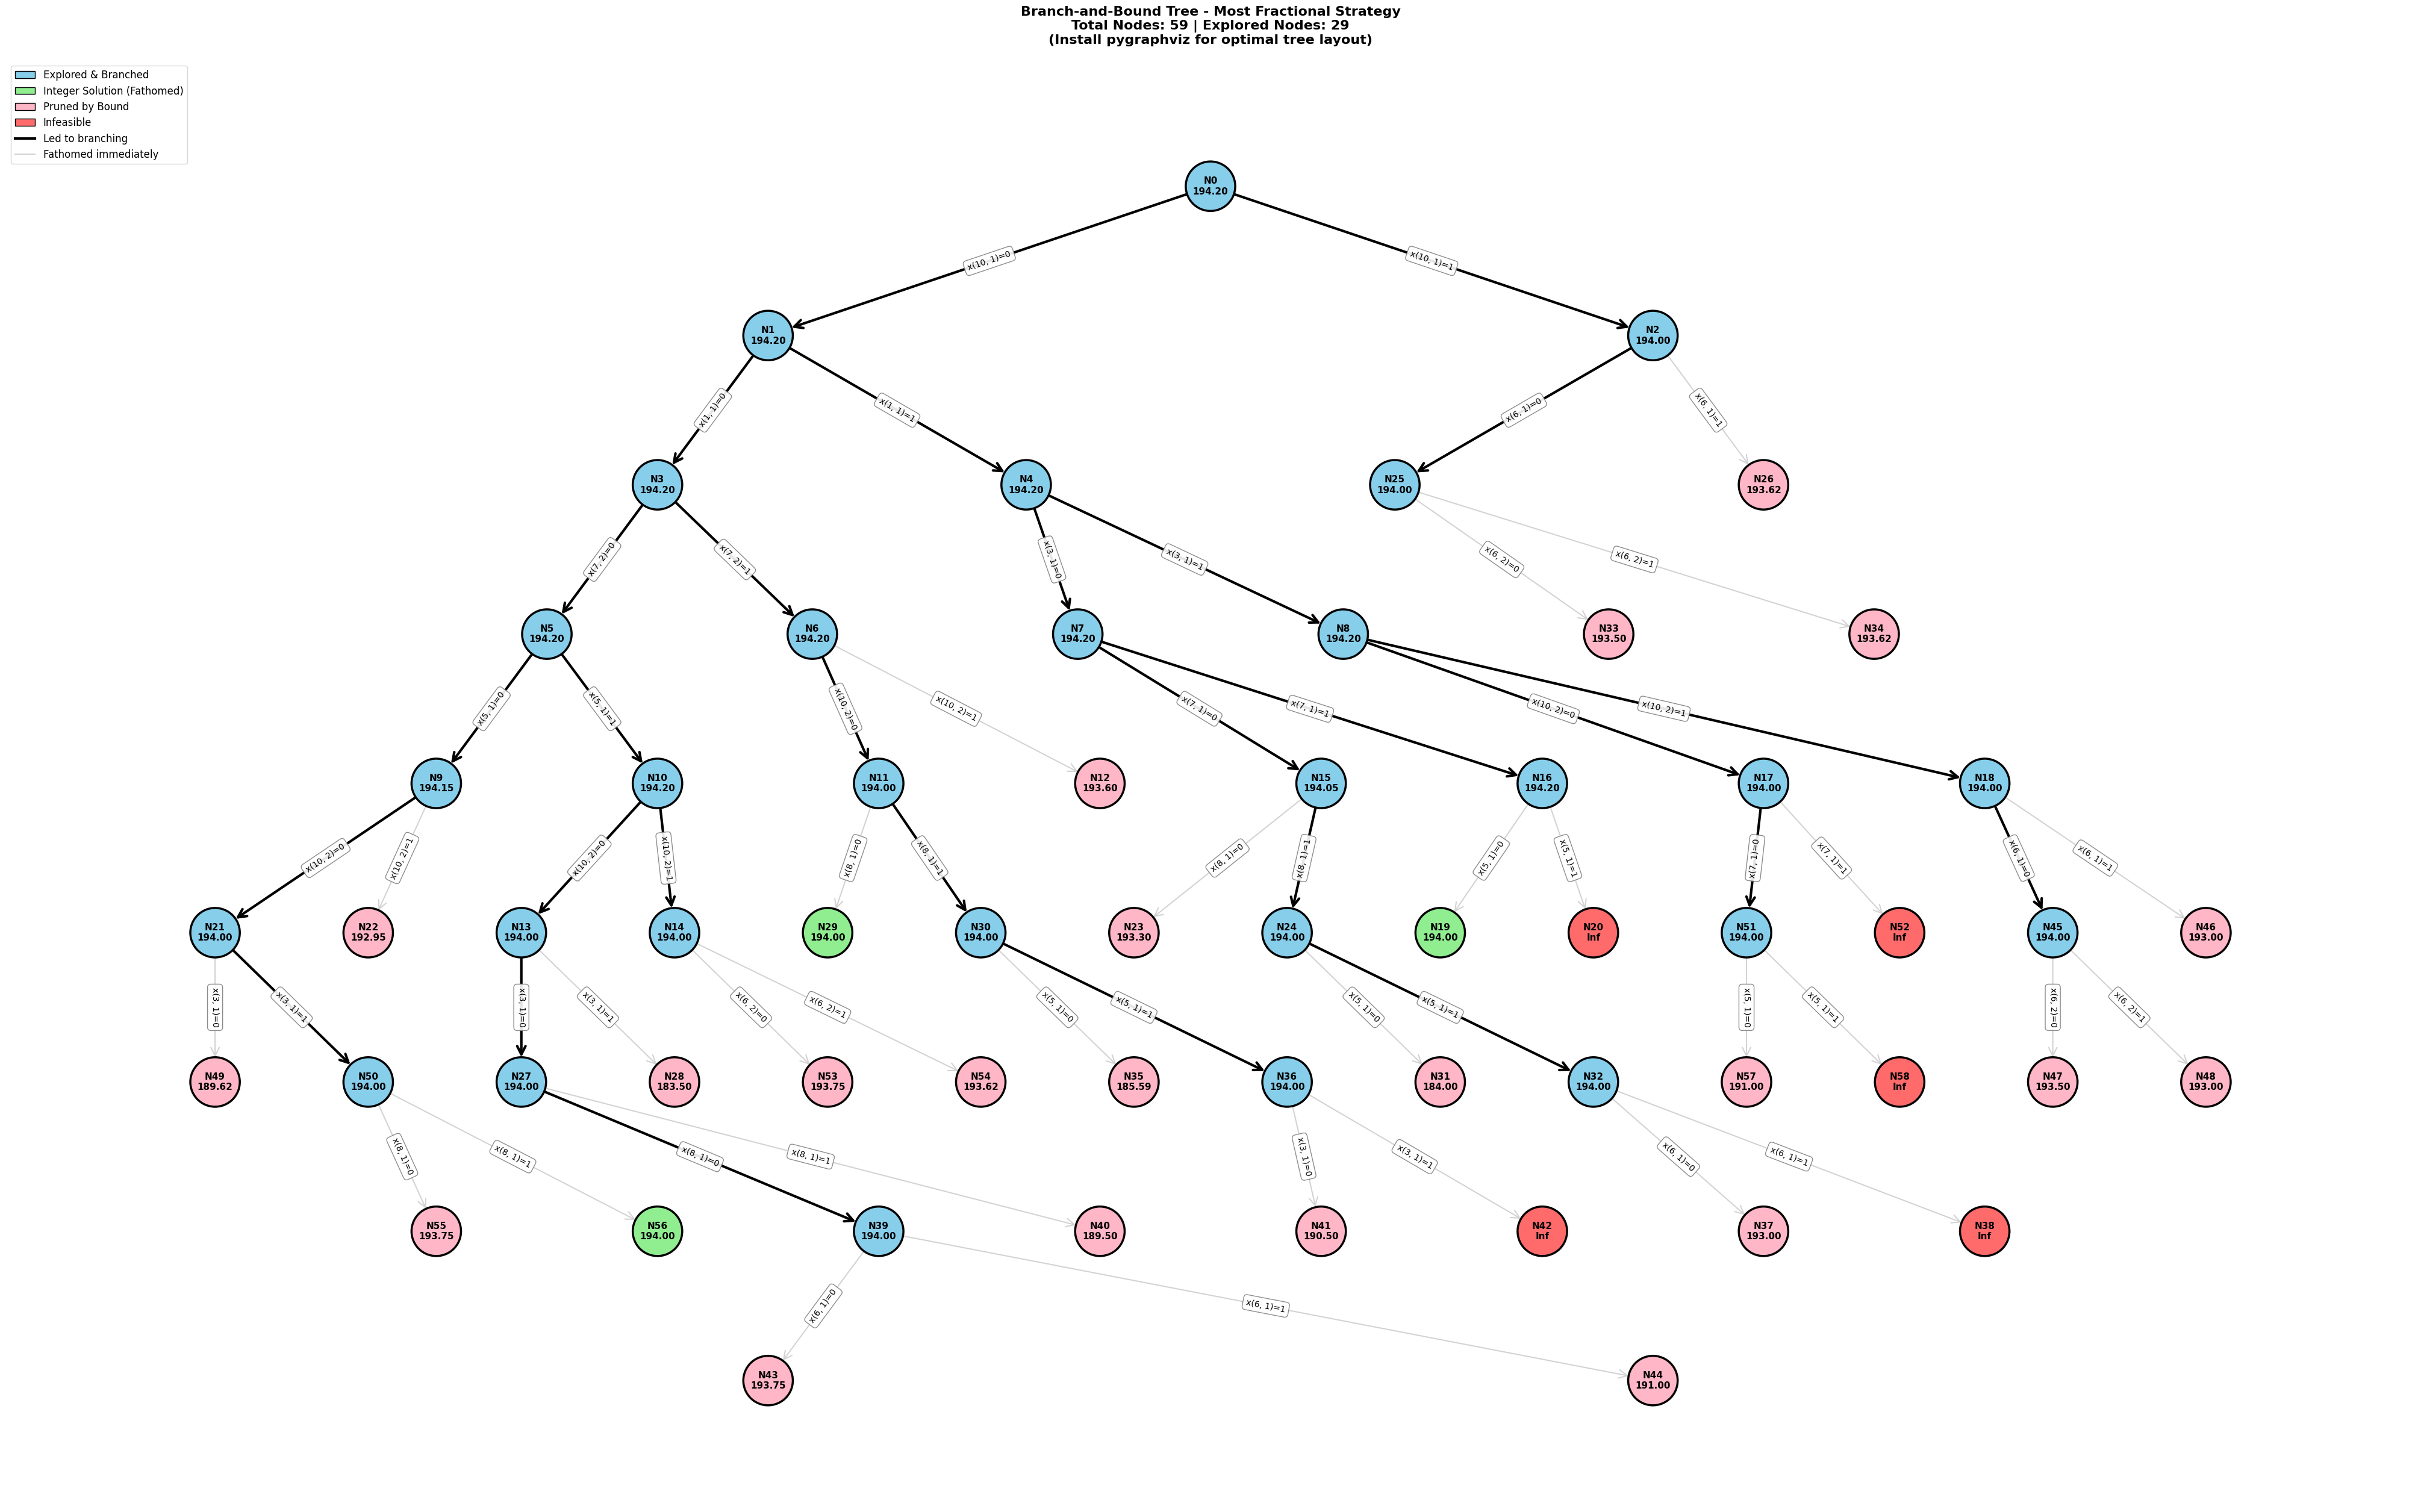




--- Starting B&B with 'strong' Strategy ---
Initial Lower Bound (Greedy Heuristic): 179
Heuristic Solution:
  Item 5 -> Knapsack 1 (profit: 60, weight: 11)
  Item 7 -> Knapsack 2 (profit: 50, weight: 10)
  Item 1 -> Knapsack 1 (profit: 22, weight: 5)
  Item 3 -> Knapsack 2 (profit: 35, weight: 8)
  Item 6 -> Knapsack 1 (profit: 12, weight: 3)
Initial Upper Bound (Root LP): 194.200
Node 29: Pruning by integrality.
*** New Incumbent Found! Node 29, Value: 194.00 ***
Node 35: Pruning by integrality.
Node 17: Pruning by integrality.
Node 6: Pruning by bound (193.62 < 194.0)
Node 10: Pruning by bound (193.62 < 194.0)
Node 12: Pruning by bound (193.62 < 194.0)
Node 16: Pruning by bound (193.62 < 194.0)
Node 9: Pruning by bound (193.50 < 194.0)
Node 15: Pruning by bound (193.50 < 194.0)
Node 30: Pruning by bound (193.10 < 194.0)
Node 27: Pruning by bound (190.50 < 194.0)
Node 23: Pruning by bound (186.50 < 194.0)
--- B&B Finished for 'strong' ---
Nodes explored (branched on): 26
Total LP s

C:\Users\Anh\AppData\Local\Temp\ipykernel_10776\2294477973.py:184: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


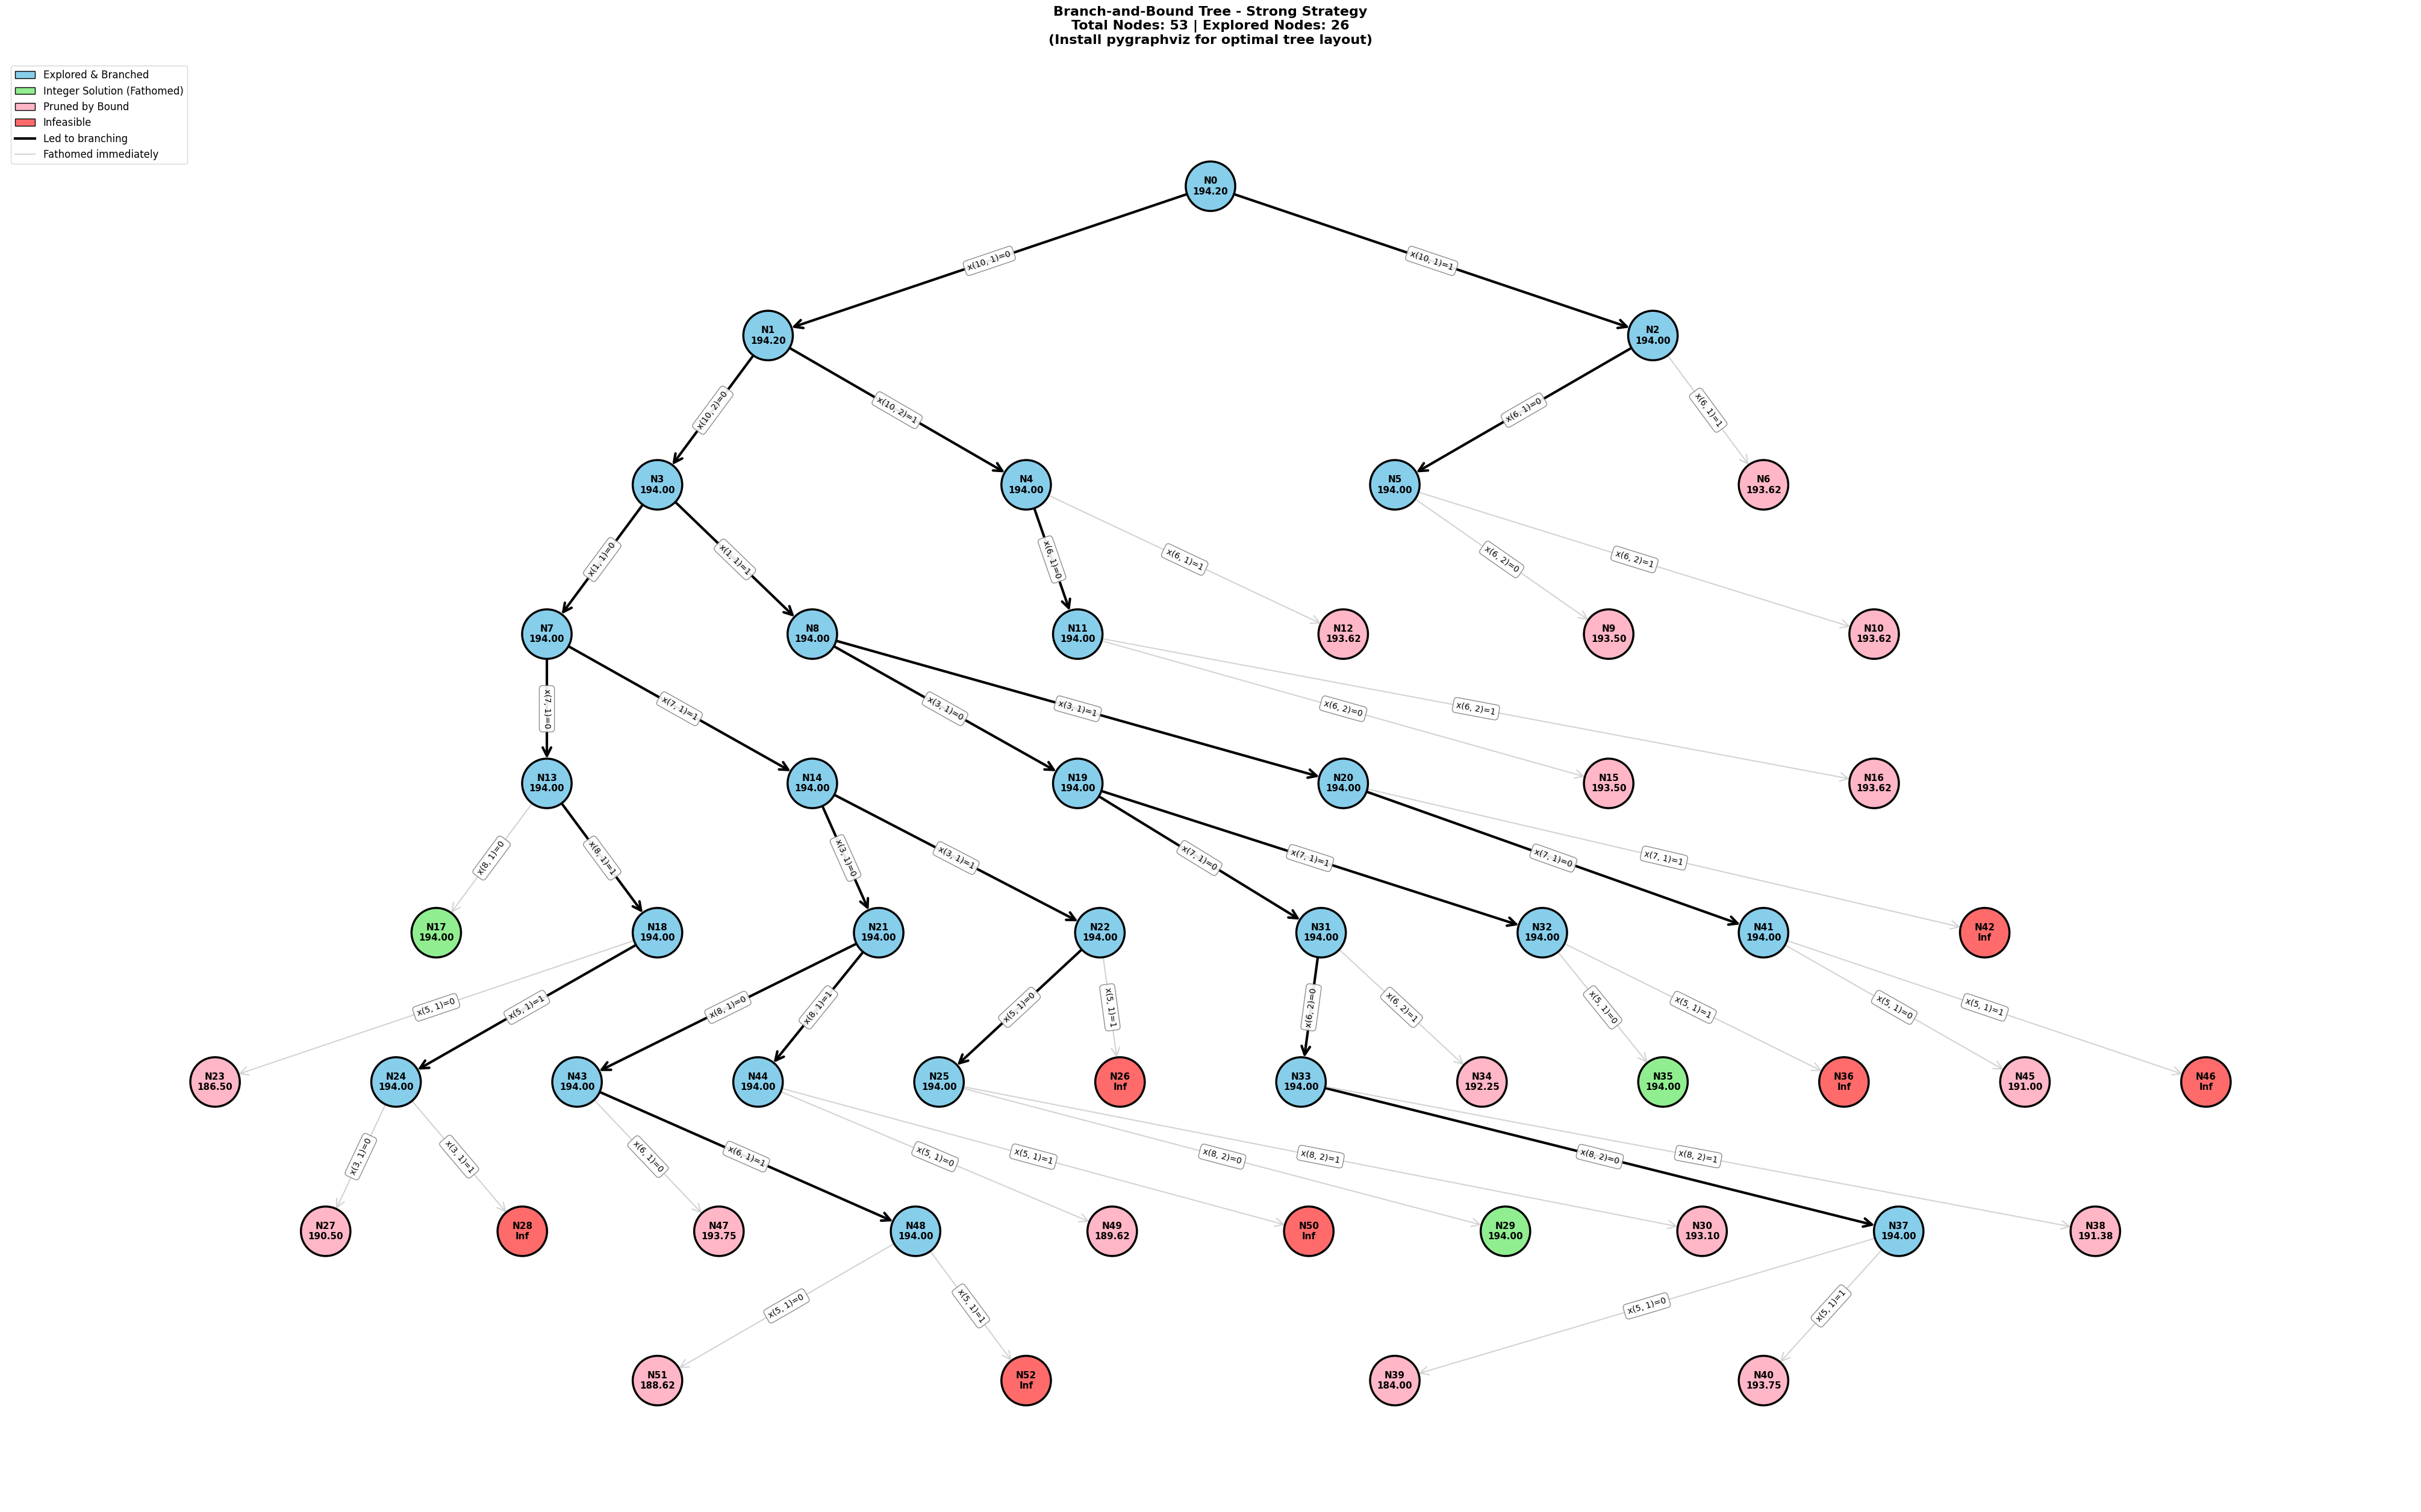



--- Final Results Summary ---
Most Fractional - Nodes explored: 29, LP solves: 59
Strong Branching - Nodes explored: 26, LP solves: 115

Strong branching explored 10.3% fewer nodes
But required 94.9% more LP solves


In [6]:
# --- 6. Main Branch-and-Bound Solver ---
def solve_branch_and_bound(branching_strategy, plot_tree=True):
    """Main B&B solver loop.
    Uses Best-Bound node selection via a PriorityQueue.
    """
    
    # --- Initialization ---
    try:
        solver = pyo.SolverFactory('gurobi_direct')
    except:
        print("Gurobi not found. Trying 'glpk'.")
        solver = pyo.SolverFactory('glpk')
    
    # Compute initial greedy heuristic solution
    global_lower_bound, best_solution = greedy_heuristic()
    
    node_count = 0  # Number of nodes actually explored (branched on)
    next_node_id = 0
    lp_solves = 0  # Total number of LP solves (including strong branching evaluations)
    
    # PriorityQueue for Best-Bound node selection.
    node_queue = PriorityQueue()
    
    # Track all nodes for visualization
    all_nodes = []

    # --- Root Node (Node 0) ---
    print(f"\n--- Starting B&B with '{branching_strategy}' Strategy ---")
    print(f"Initial Lower Bound (Greedy Heuristic): {global_lower_bound}")
    print(f"Heuristic Solution:")
    for (i, j), val in best_solution.items():
        if val > 0:
            print(f"  Item {i} -> Knapsack {j} (profit: {profits[i]}, weight: {weights[i]})")
    
    status, lp_val, lp_sol, is_int = solve_node_lp(solver, bounds_to_apply={})
    lp_solves += 1  # Count root LP solve
    
    if status != 'optimal':
        print("Root node is infeasible or unbounded. Stopping.")
        return
        
    global_upper_bound = lp_val
    print(f"Initial Upper Bound (Root LP): {global_upper_bound:.3f}")
    
    root_node = BBNode(
        node_id=next_node_id,
        parent_id=None,
        bounds_applied={},
        lp_value=lp_val,
        lp_solution=lp_sol,
        is_integer=is_int
    )
    
    all_nodes.append(root_node)
    node_queue.put(root_node)
    next_node_id += 1
    
    start_time = time.time()

    # --- B&B Loop ---
    while not node_queue.empty():
        
        # 1. Node Selection (Best-Bound)
        current_node = node_queue.get()

        # 2. Fathoming (Pruning)
        
        # a) Prune by bound: LP value is worse than our best integer solution
        if current_node.lp_value < global_lower_bound:
            current_node.was_pruned = True
            current_node.prune_reason = "Pruned by bound"
            print(f"Node {current_node.node_id}: Pruning by bound ({current_node.lp_value:.2f} < {global_lower_bound})")
            continue
            
        # b) Prune by integrality: Node is integer
        if current_node.is_integer:
            current_node.was_pruned = True
            current_node.prune_reason = "Pruned by integrality"
            print(f"Node {current_node.node_id}: Pruning by integrality.")
            # Is it a *better* integer solution?
            if current_node.lp_value > global_lower_bound:
                global_lower_bound = current_node.lp_value
                best_solution = current_node.lp_solution
                print(f"*** New Incumbent Found! Node {current_node.node_id}, Value: {global_lower_bound:.2f} ***")
            continue  # Fathomed

        # If we are here, the node is fractional and promising.
        # This node will be explored (branched on), so increment the counter
        node_count += 1
        
        # 3. Branching
        
        # Find all fractional variables
        fractional_vars = []
        for (i, j), val in current_node.lp_solution.items():
            if abs(val - round(val)) > 1e-6:
                fractional_vars.append(((i, j), val))

        if not fractional_vars:
            # Should not happen if is_integer is False, but a good safeguard
            continue

        # --- Select Branching Variable ---
        branch_var_key = None
        children_data = {}  # To store pre-computed results from strong branching
        
        if branching_strategy == "most_fractional":
            branch_var_key = select_branch_var_most_fractional(current_node.lp_solution)
        
        elif branching_strategy == "strong":
            branch_var_key, children_data, sb_lp_solves = select_branch_var_strong(
                solver, current_node.bounds_applied, fractional_vars, current_node.lp_value
            )
            lp_solves += sb_lp_solves  # Add strong branching LP solves to total

        if branch_var_key is None:
            continue
            
        # --- 4. Create Children Nodes ---
        
        for branch_val in [0, 1]:  # 0 = "down" branch, 1 = "up" branch
            
            child_bounds = current_node.bounds_applied.copy()
            child_bounds[branch_var_key] = branch_val
            
            # Check if strong branching already solved this child
            already_solved = False
            if branch_val in children_data:
                status, lp_val, lp_sol, is_int = children_data[branch_val]
                already_solved = True
            else:
                # Solve the LP for this new child node
                status, lp_val, lp_sol, is_int = solve_node_lp(solver, child_bounds)
                lp_solves += 1  # Count this LP solve

            # --- Prune child if necessary ---
            if status != 'optimal':
                # Create pruned node for visualization
                pruned_node = BBNode(
                    node_id=next_node_id,
                    parent_id=current_node.node_id,
                    bounds_applied=child_bounds,
                    lp_value=None,
                    lp_solution=None,
                    is_integer=False,
                    was_pruned=True,
                    prune_reason="Infeasible",
                    branch_var=branch_var_key,
                    branch_val=branch_val
                )
                all_nodes.append(pruned_node)
                # Only print if not already solved by strong branching
                if not already_solved:
                    print(f"Node {next_node_id}: Infeasible. Pruning.")
                next_node_id += 1
                continue  # Prune infeasible child
            
            if lp_val < global_lower_bound:
                # Create pruned node for visualization
                pruned_node = BBNode(
                    node_id=next_node_id,
                    parent_id=current_node.node_id,
                    bounds_applied=child_bounds,
                    lp_value=lp_val,
                    lp_solution=lp_sol,
                    is_integer=is_int,
                    was_pruned=True,
                    prune_reason="Pruned by bound",
                    branch_var=branch_var_key,
                    branch_val=branch_val
                )
                all_nodes.append(pruned_node)
                next_node_id += 1
                continue  # Prune by bound

            # --- Child is promising: Add to queue ---
            new_node = BBNode(
                node_id=next_node_id,
                parent_id=current_node.node_id,
                bounds_applied=child_bounds,
                lp_value=lp_val,
                lp_solution=lp_sol,
                is_integer=is_int,
                branch_var=branch_var_key,
                branch_val=branch_val
            )
            all_nodes.append(new_node)
            node_queue.put(new_node)
            next_node_id += 1

    # --- End of B&B Loop ---
    end_time = time.time()
    print(f"--- B&B Finished for '{branching_strategy}' ---")
    print(f"Nodes explored (branched on): {node_count}")
    print(f"Total LP solves: {lp_solves}")
    print(f"Best solution value found: {global_lower_bound}")
    print(f"Total time: {end_time - start_time:.4f} seconds")
    
    # Optional: Print the final solution
    print("\nFinal Solution (Item, Knapsack):")
    if isinstance(best_solution, dict):
        for (i, j), val in best_solution.items():
            if val > 0.5:
                print(f"  Item {i} -> Knapsack {j}")
    
    # Plot the tree if requested
    if plot_tree:
        plot_bb_tree(all_nodes, branching_strategy.replace('_', ' ').title())
                
    return node_count, lp_solves, all_nodes

# --- 7. Run the Solvers ---
if __name__ == "__main__":
    
    # Task 5, part 1: Most Fractional
    nodes_mf, lp_solves_mf, all_nodes_mf = solve_branch_and_bound(branching_strategy="most_fractional")
    
    print("\n" + "="*50 + "\n")
    
    # Task 5, part 2: Strong Branching
    nodes_sb, lp_solves_sb, all_nodes_sb = solve_branch_and_bound(branching_strategy="strong")
    
    print("\n" + "="*50 + "\n")
    print("--- Final Results Summary ---")
    print(f"Most Fractional - Nodes explored: {nodes_mf}, LP solves: {lp_solves_mf}")
    print(f"Strong Branching - Nodes explored: {nodes_sb}, LP solves: {lp_solves_sb}")
    print(f"\nStrong branching explored {((nodes_mf - nodes_sb) / nodes_mf * 100):.1f}% fewer nodes")
    print(f"But required {((lp_solves_sb / lp_solves_mf - 1) * 100):.1f}% more LP solves")

5.
When solving the subproblems in strong branching, other useful information is gained.

First, variables can be fixed automatically. When a variable is tested, it might be found that setting it to one value (like 0) makes the problem impossible to solve, or infeasible. It is then proven that the variable must equal the other value (like 1) for any good solution. This rule can be added to the current problem without needing to branch, which makes the problem simpler and stronger.

Second, a branch can be pruned immediately. Both options (like 0 and 1) are tested. If the best integer solution found so far is 194, and the test of one option (like $x=1$) shows its best possible LP value is only 190, that entire branch is known to be a dead end. That option can be discarded, and the search can be continued by forcing the other option ($x=0$).